# Customer Churn Prediction Analysis

This notebook analyzes and predicts customer churn using machine learning techniques.

## 1. Import Required Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore Dataset

In [16]:
# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names and data types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (7043, 20)

First few rows:
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   ID_00000    Male              1      No        Yes      28          Yes   
1   ID_00001  Female              1      No        Yes      67          Yes   
2   ID_00002    Male              1      No         No      16           No   
3   ID_00003    Male              1     Yes        Yes       4          Yes   
4   ID_00004    Male              1     Yes        Yes      49          Yes   

  InternetService       OnlineSecurity         OnlineBackup  \
0     Fiber optic                   No                   No   
1             DSL                   No                  Yes   
2              No                   No  No internet service   
3              No                  Yes                   No   
4              No  No internet service                  Yes   

      DeviceProtection          TechSupport          StreamingTV  \
0  No internet service             

## 3. Data Preprocessing and Cleaning

In [15]:
# Create a copy for preprocessing
df_processed = df.copy()

# Handle missing values
print("Checking for missing values...")
print(df_processed.isnull().sum().sum())

# Remove duplicates
df_processed = df_processed.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df_processed.shape}")

# Encode categorical variables
le_dict = {}
categorical_cols = df_processed.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    le_dict[col] = le

print(f"\nCategorical columns encoded: {list(categorical_cols)}")

Checking for missing values...
0
Dataset shape after removing duplicates: (7043, 20)

Categorical columns encoded: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## 4. Exploratory Data Analysis (EDA)

Churn distribution:
Churn
No     5143
Yes    1900
Name: count, dtype: int64

Churn rate: 26.98%


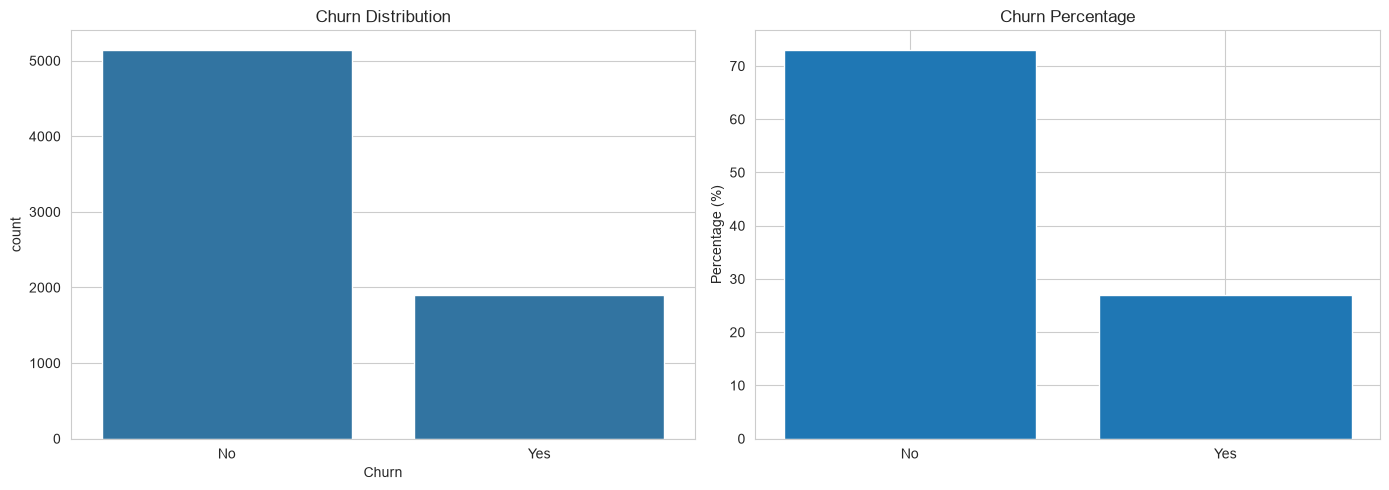


Correlation with Churn:
Churn               1.000000
StreamingTV         0.017232
StreamingMovies     0.016835
DeviceProtection    0.015894
PaymentMethod       0.013764
gender              0.011076
TotalCharges        0.010797
customerID          0.008992
OnlineSecurity      0.008558
PhoneService        0.000577
Name: Churn, dtype: float64


In [14]:
# Churn distribution
print("Churn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {(df['Churn'] == 'Yes').sum() / len(df) * 100:.2f}%")

# Visualize churn distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Churn count
sns.countplot(data=df, x='Churn', ax=ax[0])
ax[0].set_title('Churn Distribution')

# Churn percentage
churn_pct = df['Churn'].value_counts() / len(df) * 100
ax[1].bar(churn_pct.index, churn_pct.values)
ax[1].set_title('Churn Percentage')
ax[1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

# Correlation analysis
print("\nCorrelation with Churn:")
correlation = df_processed.corr()['Churn'].sort_values(ascending=False)
print(correlation.head(10))

## 5. Feature Engineering

In [13]:
# Separate features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Select features based on correlation with churn
correlation_with_churn = df_processed.corr()['Churn'].abs().sort_values(ascending=False)
top_features = correlation_with_churn[1:16].index.tolist()  # Select top 15 features
print(f"\nTop 15 features correlated with Churn:")
print(top_features)

# Use all features for now
X_selected = X.copy()

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
X_scaled = pd.DataFrame(X_scaled, columns=X_selected.columns)

print(f"\nFeatures prepared for modeling: {X_scaled.shape}")

Features shape: (7043, 19)
Target shape: (7043,)

Top 15 features correlated with Churn:
['StreamingTV', 'StreamingMovies', 'DeviceProtection', 'PaymentMethod', 'PaperlessBilling', 'gender', 'Contract', 'TotalCharges', 'TechSupport', 'customerID', 'OnlineSecurity', 'SeniorCitizen', 'Partner', 'MonthlyCharges', 'InternetService']

Features prepared for modeling: (7043, 19)


## 6. Build Predictive Models

In [12]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} training completed!")

print("\nAll models trained successfully!")

Training set size: (5634, 19)
Testing set size: (1409, 19)

Training Logistic Regression...
Logistic Regression training completed!

Training Random Forest...
Random Forest training completed!

Training Gradient Boosting...
Gradient Boosting training completed!

All models trained successfully!


## 7. Model Evaluation and Comparison


Logistic Regression Performance:
  Accuracy: 0.7303
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  ROC-AUC: 0.5087

Random Forest Performance:
  Accuracy: 0.7303
  Precision: 0.5000
  Recall: 0.0026
  F1-Score: 0.0052
  ROC-AUC: 0.5066

Gradient Boosting Performance:
  Accuracy: 0.7282
  Precision: 0.2000
  Recall: 0.0026
  F1-Score: 0.0052
  ROC-AUC: 0.4947

Model Comparison
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.730305        0.0  0.000000  0.000000  0.508665
Random Forest        0.730305        0.5  0.002632  0.005236  0.506562
Gradient Boosting    0.728176        0.2  0.002632  0.005195  0.494675


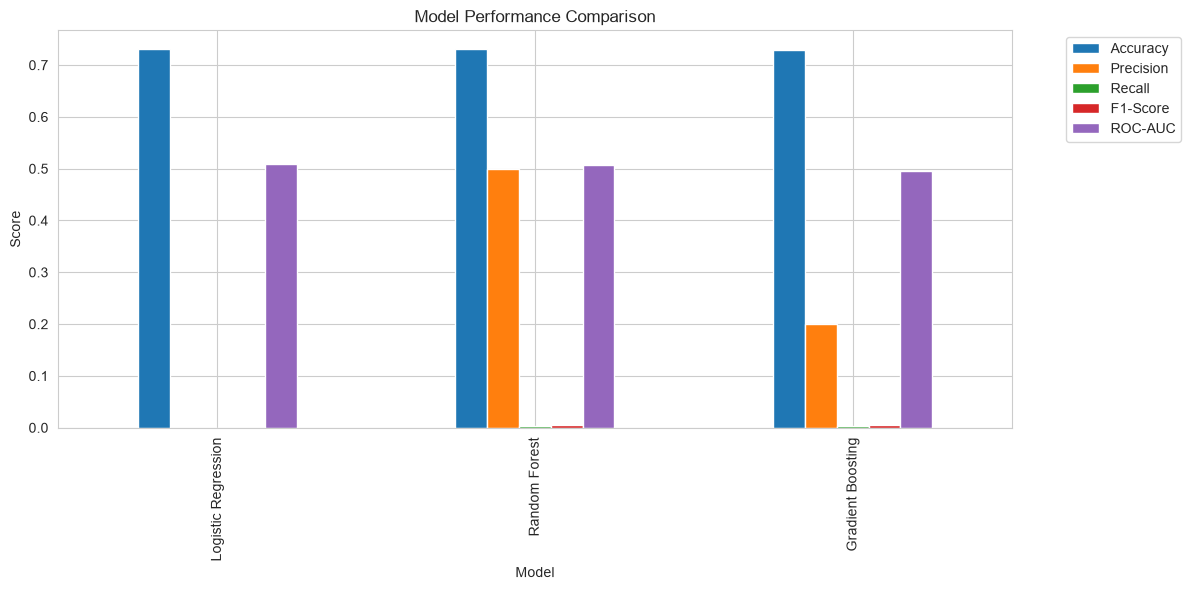

In [11]:
# Evaluate all models
results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"\n{name} Performance:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

# Create comparison dataframe
results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("Model Comparison")
print("="*60)
print(results_df)

# Visualize model comparison
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

Top 15 Most Important Features (Random Forest):
             Feature  Importance
17    MonthlyCharges    0.141467
0         customerID    0.140858
18      TotalCharges    0.137962
5             tenure    0.122093
16     PaymentMethod    0.044768
7    InternetService    0.036148
8     OnlineSecurity    0.036066
10  DeviceProtection    0.035891
14          Contract    0.035496
13   StreamingMovies    0.035295
9       OnlineBackup    0.034958
12       StreamingTV    0.034809
11       TechSupport    0.033714
3            Partner    0.022136
6       PhoneService    0.022087


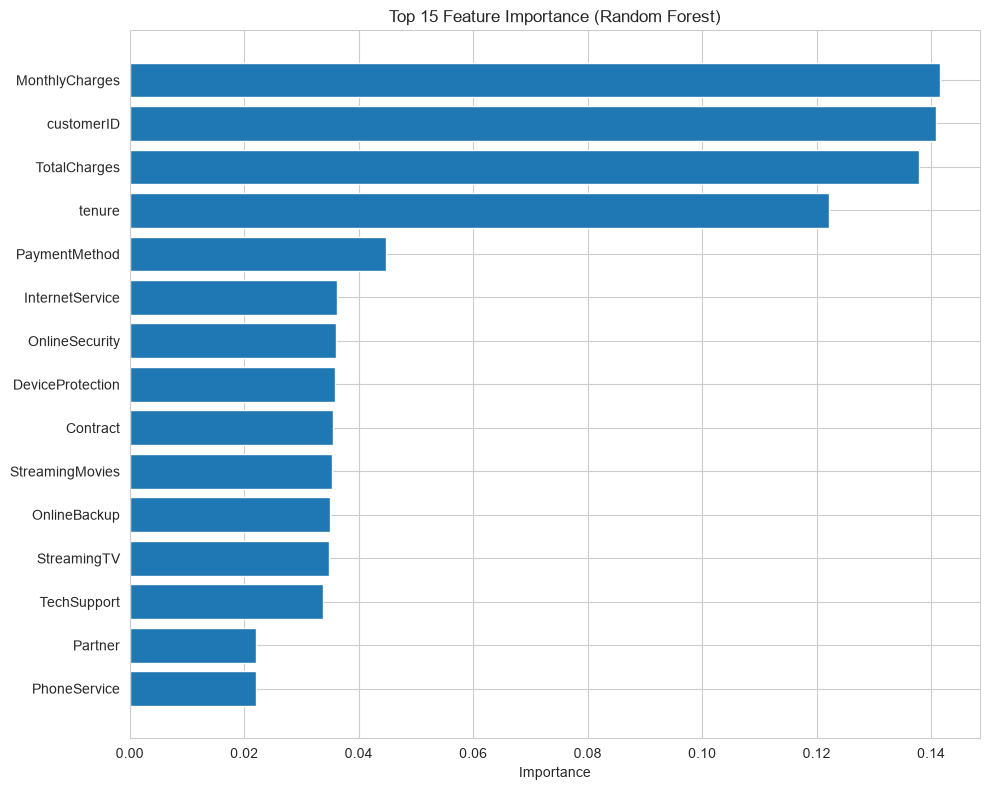


Top 15 Most Important Features (Gradient Boosting):
             Feature  Importance
17    MonthlyCharges    0.293542
0         customerID    0.236638
18      TotalCharges    0.213863
5             tenure    0.089034
16     PaymentMethod    0.021643
13   StreamingMovies    0.020753
11       TechSupport    0.019611
14          Contract    0.018902
12       StreamingTV    0.018447
10  DeviceProtection    0.015002
1             gender    0.011038
15  PaperlessBilling    0.010803
6       PhoneService    0.010451
7    InternetService    0.009393
8     OnlineSecurity    0.005382


In [10]:
# Feature importance from Random Forest
rf_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features (Random Forest):")
print(feature_importance.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_15_features = feature_importance.head(15)
plt.barh(range(len(top_15_features)), top_15_features['Importance'])
plt.yticks(range(len(top_15_features)), top_15_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Feature importance from Gradient Boosting
gb_model = trained_models['Gradient Boosting']
gb_feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Gradient Boosting):")
print(gb_feature_importance.head(15))